# Notebook 5 — Comparación Final de Modelos
**Objetivo:** Comparar todos los modelos (LSTM, BiGRU, Conv1D+BiLSTM) en ambos datasets y extraer conclusiones sobre el mejor enfoque para clasificación de sentimiento en español.

## 1. Setup y Carga de Métricas

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

BASE_DIR = "results"
DIRS = {k: os.path.join(BASE_DIR, k) for k in ["data","figures","models","metrics"]}

def load_metrics(model_type):
    path = os.path.join(DIRS["metrics"], f"{model_type}_results.json")
    with open(path) as f:
        return json.load(f)

lstm_results    = load_metrics("LSTM")
bigru_results   = load_metrics("BiGRU")
convlstm_results= load_metrics("ConvLSTM")

all_results = lstm_results + bigru_results + convlstm_results
print(f"✅ Total de experimentos cargados: {len(all_results)}")

✅ Total de experimentos cargados: 18


## 2. Tabla Comparativa Global

In [2]:
rows = []
for res in all_results:
    model_family = res['config'].split('_')[0]
    rows.append({
        "Familia":   model_family,
        "Config":    res['config'],
        "Dataset":   res['dataset'],
        "Accuracy":  res['metrics']['accuracy'],
        "Precision": res['metrics']['precision'],
        "Recall":    res['metrics']['recall'],
        "F1-Score":  res['metrics']['f1'],
        "ROC-AUC":   res['metrics']['roc_auc'],
        "Params":    res.get('params', 0),
    })

df_all = pd.DataFrame(rows)

# Formatear para display
df_display = df_all.copy()
for col in ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]:
    df_display[col] = df_display[col].map(lambda x: f"{x:.4f}")
df_display["Params"] = df_display["Params"].map(lambda x: f"{x:,}")

print("\n" + "="*80)
print("  RESULTADOS COMPLETOS — TODOS LOS MODELOS")
print("="*80)
display(df_display)

# Guardar CSV
path = os.path.join(DIRS["metrics"], "ALL_models_comparison.csv")
df_all.to_csv(path, index=False)
print(f"\n✅ Guardada en: {path}")


  RESULTADOS COMPLETOS — TODOS LOS MODELOS


,Familia,Config,Dataset,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Params
0,LSTM,LSTM_C1_Simple,balanced,0.9794,0.9638,0.9963,0.9797,0.9981,"1,189,249"
1,LSTM,LSTM_C2_Medium,balanced,0.9869,0.9815,0.9925,0.9870,0.9994,"2,448,129"
2,LSTM,LSTM_C3_Stacked,balanced,0.9888,0.9780,1.0000,0.9889,1.0000,"2,495,489"
3,LSTM,LSTM_C4_Deep,balanced,0.9888,0.9780,1.0000,0.9889,0.9997,"5,404,929"
4,LSTM,LSTM_C1_Simple,big_ahr,0.9767,0.9871,0.9849,0.9860,0.9932,"1,315,137"
5,LSTM,LSTM_C2_Medium,big_ahr,0.9761,0.9901,0.9811,0.9856,0.9930,"2,699,905"
6,LSTM,LSTM_C3_Stacked,big_ahr,0.9692,0.9833,0.9796,0.9814,0.9933,"2,747,265"
7,LSTM,LSTM_C4_Deep,big_ahr,0.9717,0.9819,0.9841,0.9830,0.9934,"5,908,481"
8,BiGRU,BiGRU_C1_Simple,balanced,0.9925,0.9852,1.0000,0.9926,0.9999,"1,208,193"
9,BiGRU,BiGRU_C2_Medium,balanced,0.9907,0.9888,0.9925,0.9907,0.9999,"2,522,881"



✅ Guardada en: results/metrics/ALL_models_comparison.csv


## 3. Gráficas de Comparación Global

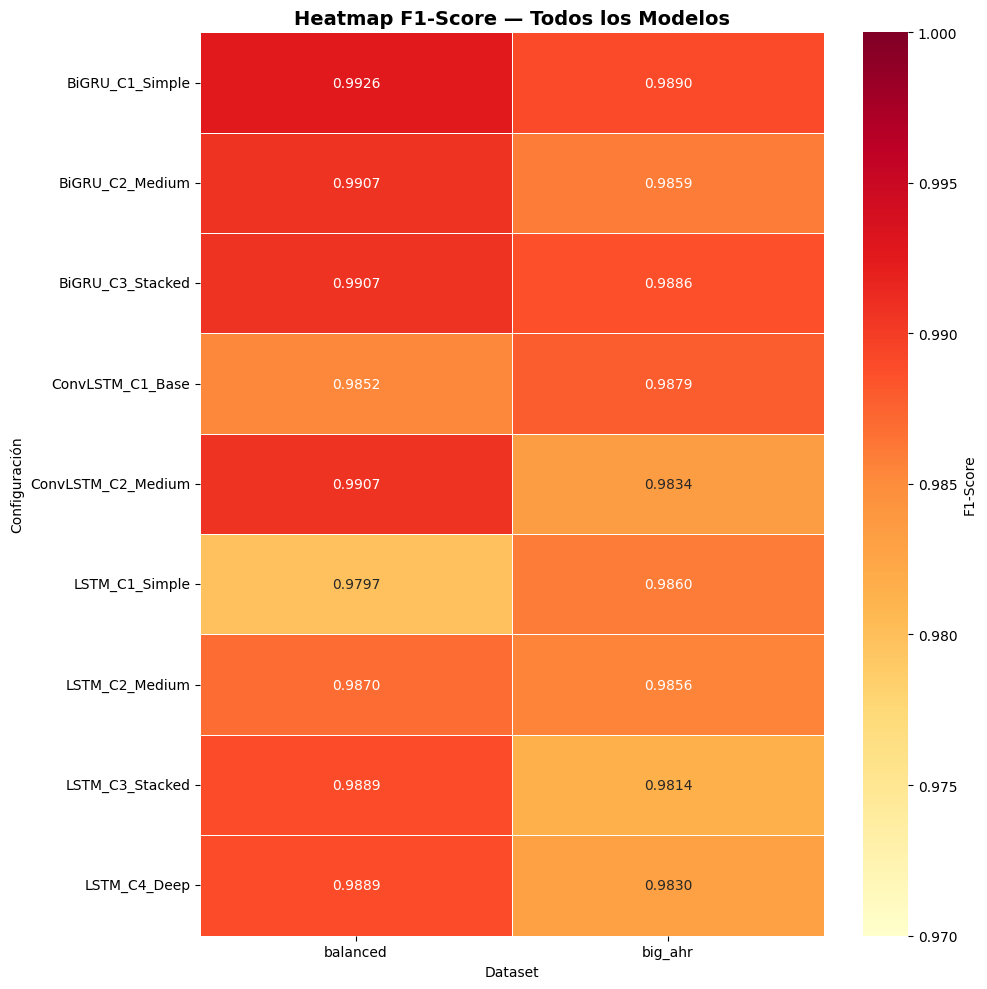

In [6]:
# ── 3.1 Heatmap de F1-Score ──────────────────────────────
pivot_f1 = df_all.pivot_table(index="Config", columns="Dataset", values="F1-Score")
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(pivot_f1, annot=True, fmt=".4f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, vmin=0.97, vmax=1.0,
            cbar_kws={'label': 'F1-Score'})
ax.set_title("Heatmap F1-Score — Todos los Modelos", fontsize=14, fontweight='bold')
ax.set_xlabel("Dataset"); ax.set_ylabel("Configuración")
plt.xticks(rotation=0); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(DIRS["figures"], "FINAL_f1_heatmap.png"), dpi=150)
plt.show()

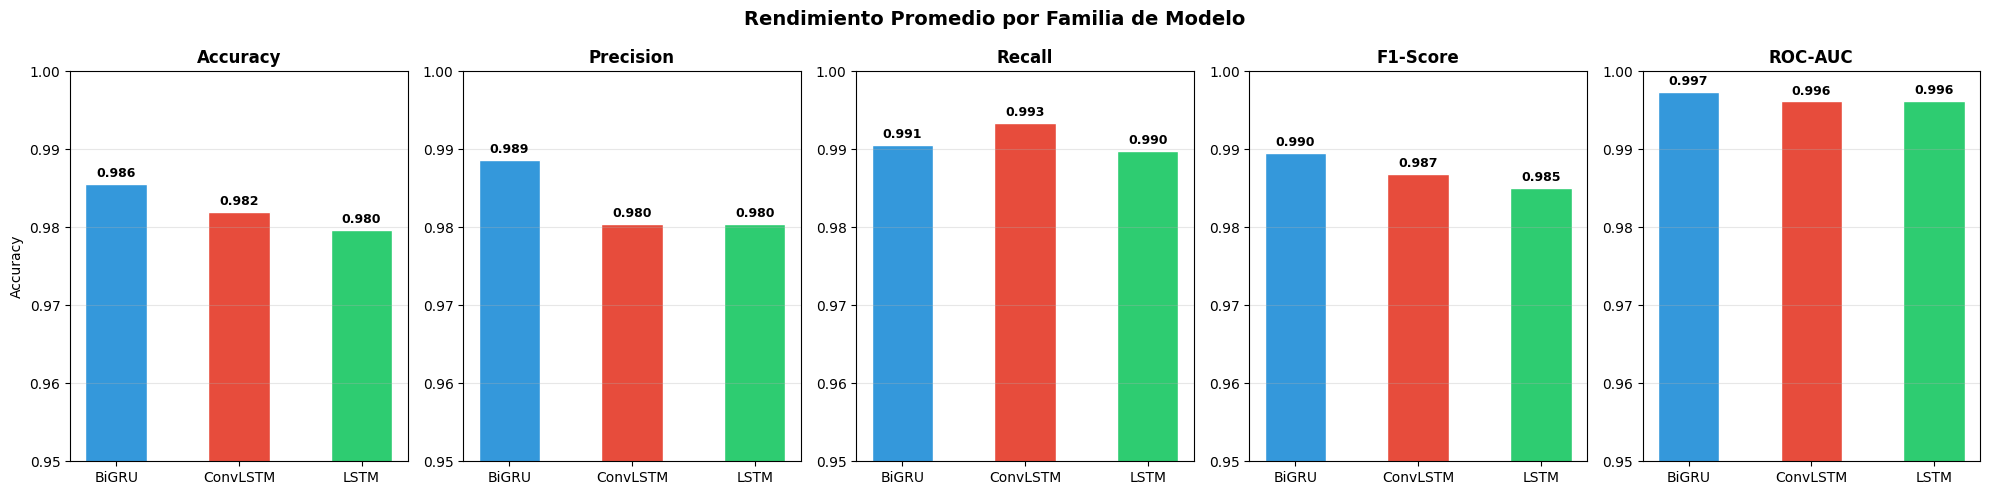

In [12]:
# ── 3.2 Barplot por familia (promedio ambos datasets) ────
metrics_cols = ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]
df_avg = df_all.groupby("Familia")[metrics_cols].mean().reset_index()

fig, axes = plt.subplots(1, len(metrics_cols), figsize=(20, 5))
fig.suptitle("Rendimiento Promedio por Familia de Modelo", fontsize=14, fontweight='bold')
colors = ['#3498db','#e74c3c','#2ecc71']
for ax, metric in zip(axes, metrics_cols):
    bars = ax.bar(df_avg["Familia"], df_avg[metric], color=colors, edgecolor='white', width=0.5)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0.95, 1.0)
    ax.set_ylabel(metric if metric == "Accuracy" else "")
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, df_avg[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005,
                f"{val:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DIRS["figures"], "FINAL_avg_by_family.png"), dpi=150)
plt.show()

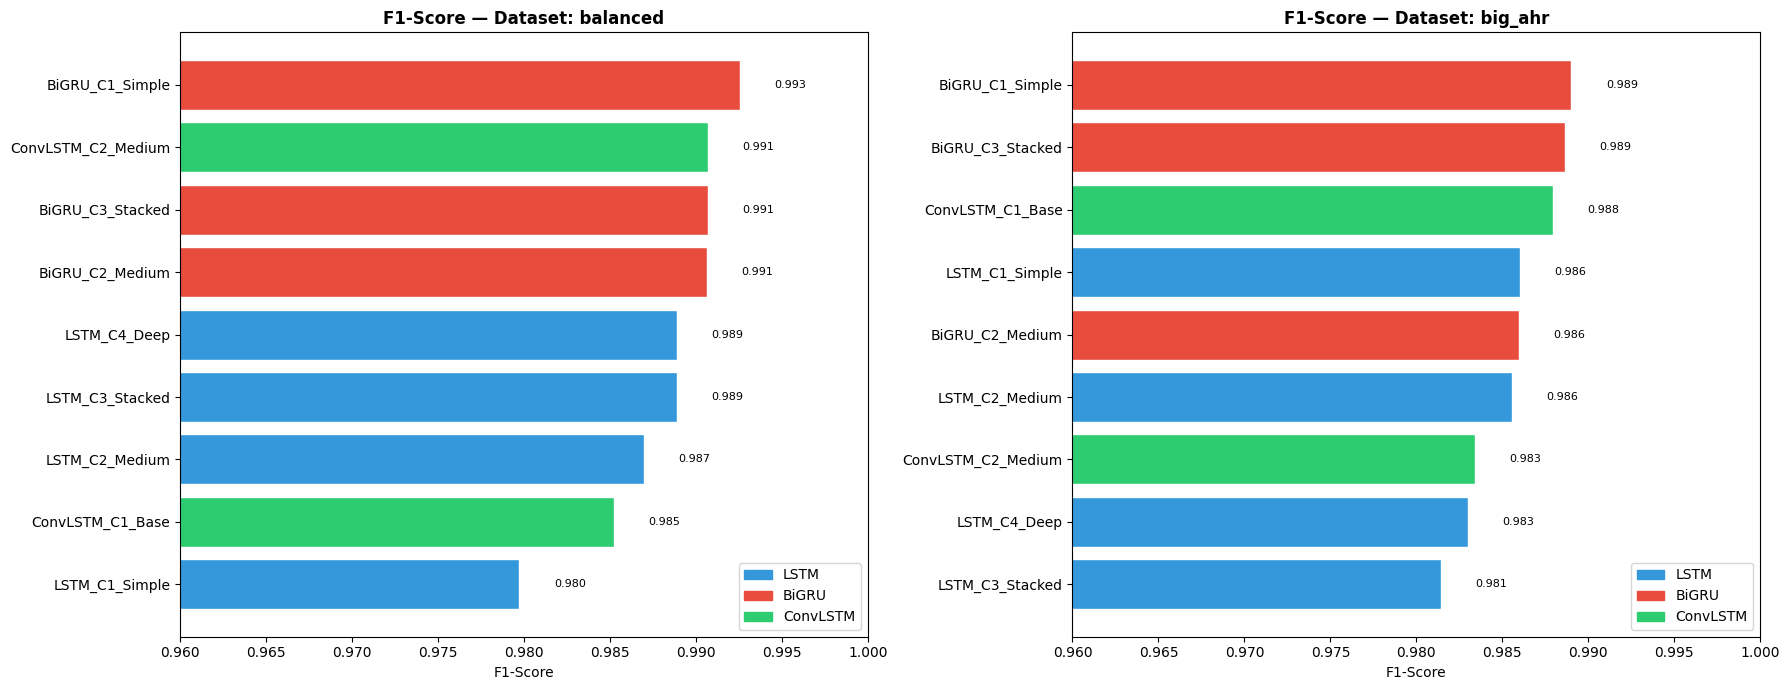

In [13]:
# ── 3.3 Comparación por dataset ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, ds in zip(axes, ["balanced","big_ahr"]):
    sub = df_all[df_all.Dataset == ds].sort_values("F1-Score", ascending=True)
    colors_map = {"LSTM":"#3498db","BiGRU":"#e74c3c","ConvLSTM":"#2ecc71"}
    bar_colors = [colors_map.get(r.Familia,"gray") for _, r in sub.iterrows()]
    bars = ax.barh(sub["Config"], sub["F1-Score"], color=bar_colors, edgecolor='white')
    ax.set_title(f"F1-Score — Dataset: {ds}", fontsize=12, fontweight='bold')
    ax.set_xlabel("F1-Score"); ax.set_xlim(0.96, 1.0)
    ax.axvline(0.9, color='red', linestyle='--', alpha=0.5, label='F1=0.90')
    for bar, val in zip(bars, sub["F1-Score"]):
        ax.text(val+0.002, bar.get_y()+bar.get_height()/2,
                f"{val:.3f}", va='center', fontsize=8)
    from matplotlib.patches import Patch
    legend = [Patch(color=v, label=k) for k, v in colors_map.items()]
    ax.legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(DIRS["figures"], "FINAL_f1_by_dataset.png"), dpi=150)
plt.show()

## 4. Top Modelos por Dataset

In [14]:
print("\n" + "="*65)
print("  TOP 3 MODELOS POR DATASET (según F1-Score)")
print("="*65)
for ds in ["balanced", "big_ahr"]:
    sub = df_all[df_all.Dataset==ds].sort_values("F1-Score", ascending=False).head(3)
    print(f"\n  Dataset: {ds.upper()}")
    print(f"  {'Rank':<5} {'Modelo':<35} {'F1':>7} {'AUC':>8} {'Params':>12}")
    print("  " + "-"*67)
    for rank, (_, row) in enumerate(sub.iterrows(), 1):
        print(f"  {rank:<5} {row['Config']:<35} {row['F1-Score']:>7.4f} "
              f"{row['ROC-AUC']:>8.4f} {int(row['Params']):>12,}")


  TOP 3 MODELOS POR DATASET (según F1-Score)

  Dataset: BALANCED
  Rank  Modelo                                   F1      AUC       Params
  -------------------------------------------------------------------
  1     BiGRU_C1_Simple                      0.9926   0.9999    1,208,193
  2     ConvLSTM_C2_Medium                   0.9907   0.9996    2,613,441
  3     BiGRU_C3_Stacked                     0.9907   0.9998    2,640,385

  Dataset: BIG_AHR
  Rank  Modelo                                   F1      AUC       Params
  -------------------------------------------------------------------
  1     BiGRU_C1_Simple                      0.9890   0.9948    1,334,081
  2     BiGRU_C3_Stacked                     0.9886   0.9949    2,892,161
  3     ConvLSTM_C1_Base                     0.9879   0.9947    1,362,817


## 5. Análisis de Hiperparámetros

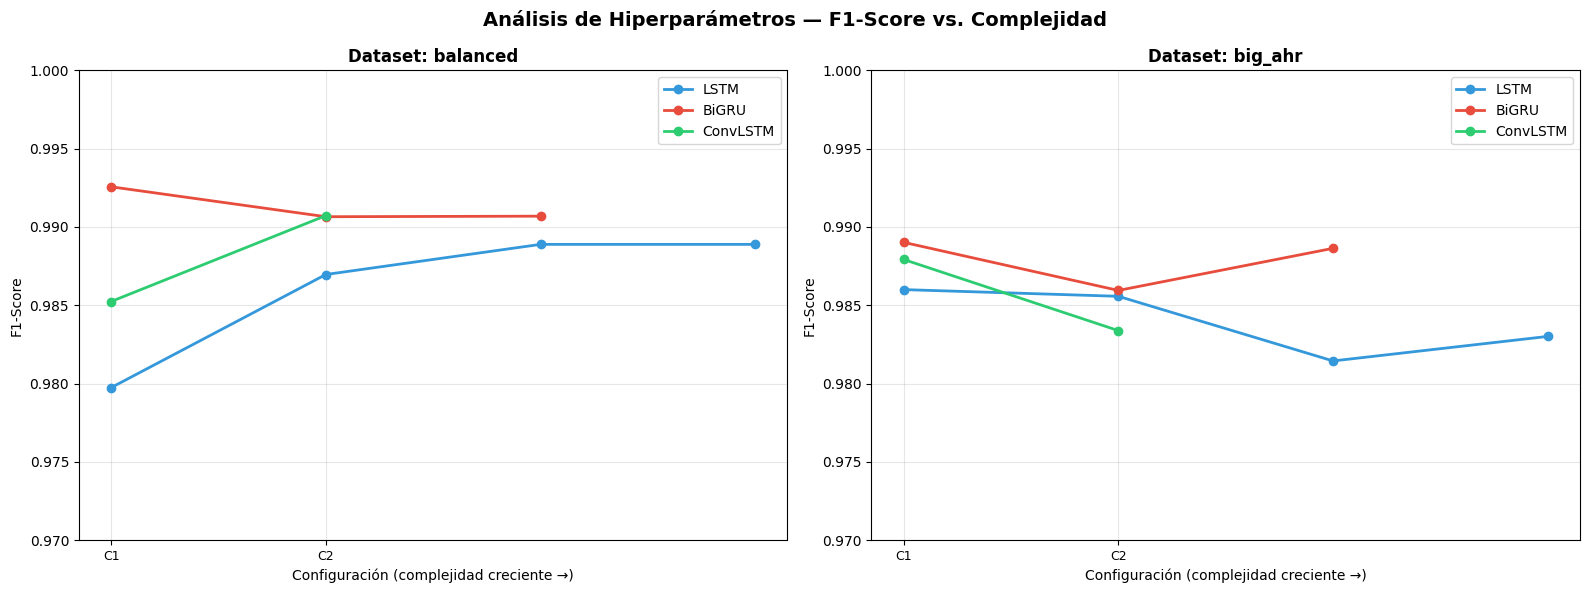

In [16]:
# Evolución del F1-Score por nivel de complejidad
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Análisis de Hiperparámetros — F1-Score vs. Complejidad",
             fontsize=14, fontweight='bold')

families = {"LSTM": "#3498db", "BiGRU": "#e74c3c", "ConvLSTM": "#2ecc71"}

for ax, ds in zip(axes, ["balanced","big_ahr"]):
    sub = df_all[df_all.Dataset == ds]
    for family, color in families.items():
        fam_data = sub[sub.Familia == family].sort_values("Config")
        configs  = [c.split("_C")[1].split("_")[0] for c in fam_data["Config"]]
        configs  = [f"C{c}" for c in configs]
        ax.plot(range(len(fam_data)), fam_data["F1-Score"],
                marker='o', linewidth=2, color=color, label=family)
        ax.set_xticks(range(len(fam_data)))
        ax.set_xticklabels(configs[:len(fam_data)], fontsize=9)

    ax.set_title(f"Dataset: {ds}", fontweight='bold')
    ax.set_xlabel("Configuración (complejidad creciente →)")
    ax.set_ylabel("F1-Score"); ax.set_ylim(0.97, 1.0)
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DIRS["figures"], "FINAL_hyperparam_analysis.png"), dpi=150)
plt.show()

## 6. Eficiencia: F1-Score vs. Parámetros

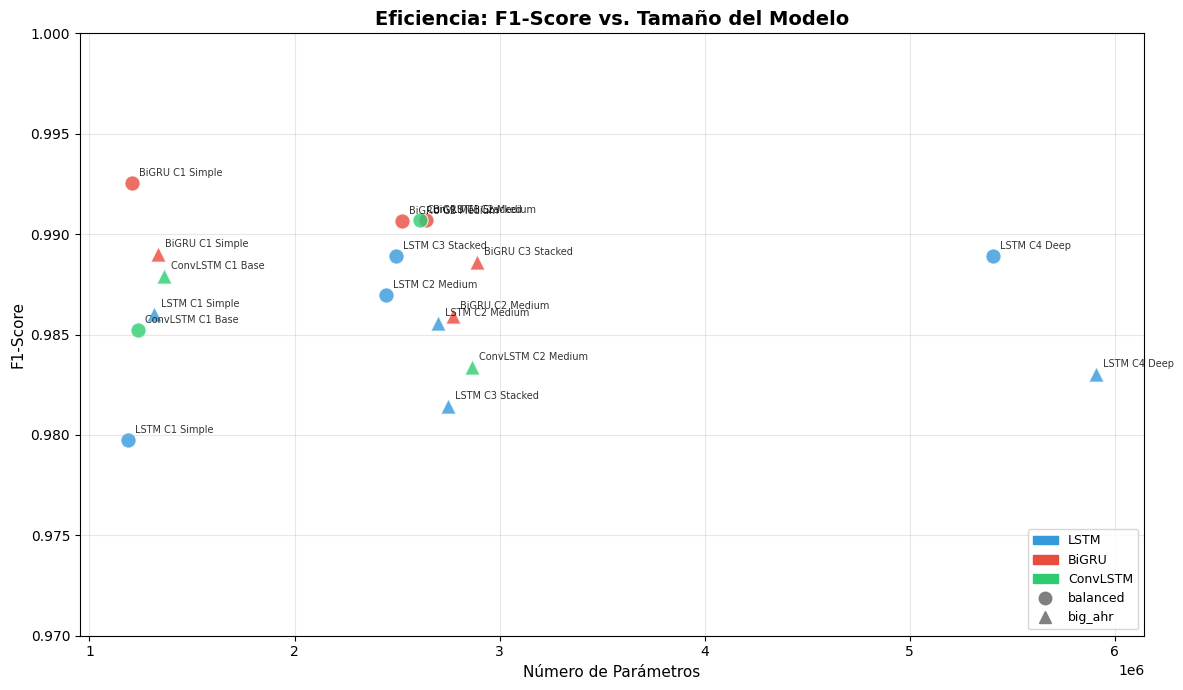

In [18]:
fig, ax = plt.subplots(figsize=(12, 7))
colors_map = {"LSTM":"#3498db","BiGRU":"#e74c3c","ConvLSTM":"#2ecc71"}
markers    = {"balanced":"o","big_ahr":"^"}

for ds in ["balanced","big_ahr"]:
    sub = df_all[df_all.Dataset == ds]
    for _, row in sub.iterrows():
        clr = colors_map.get(row['Familia'],'gray')
        ax.scatter(row['Params'], row['F1-Score'],
                   c=clr, marker=markers[ds], s=120, alpha=0.8,
                   edgecolors='white', linewidth=0.8)
        ax.annotate(row['Config'].replace("_"," "),
                    (row['Params'], row['F1-Score']),
                    textcoords="offset points", xytext=(5,5), fontsize=7, alpha=0.8)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_family = [Patch(color=v, label=k) for k, v in colors_map.items()]
legend_ds     = [Line2D([0],[0], marker=m, color='gray', linestyle='', label=ds, markersize=9)
                 for ds, m in markers.items()]
ax.legend(handles=legend_family+legend_ds, loc='lower right', fontsize=9)
ax.set_xlabel("Número de Parámetros", fontsize=11)
ax.set_ylabel("F1-Score", fontsize=11)
ax.set_title("Eficiencia: F1-Score vs. Tamaño del Modelo", fontsize=14, fontweight='bold')
ax.grid(alpha=0.3); ax.set_ylim(0.97, 1.0)
plt.tight_layout()
plt.savefig(os.path.join(DIRS["figures"], "FINAL_efficiency_scatter.png"), dpi=150)
plt.show()

## 7. Curvas de Entrenamiento — Mejores Modelos

  Mejor modelo [balanced]: BiGRU_C1_Simple (F1=0.9926)
  Mejor modelo [big_ahr]: BiGRU_C1_Simple (F1=0.9890)


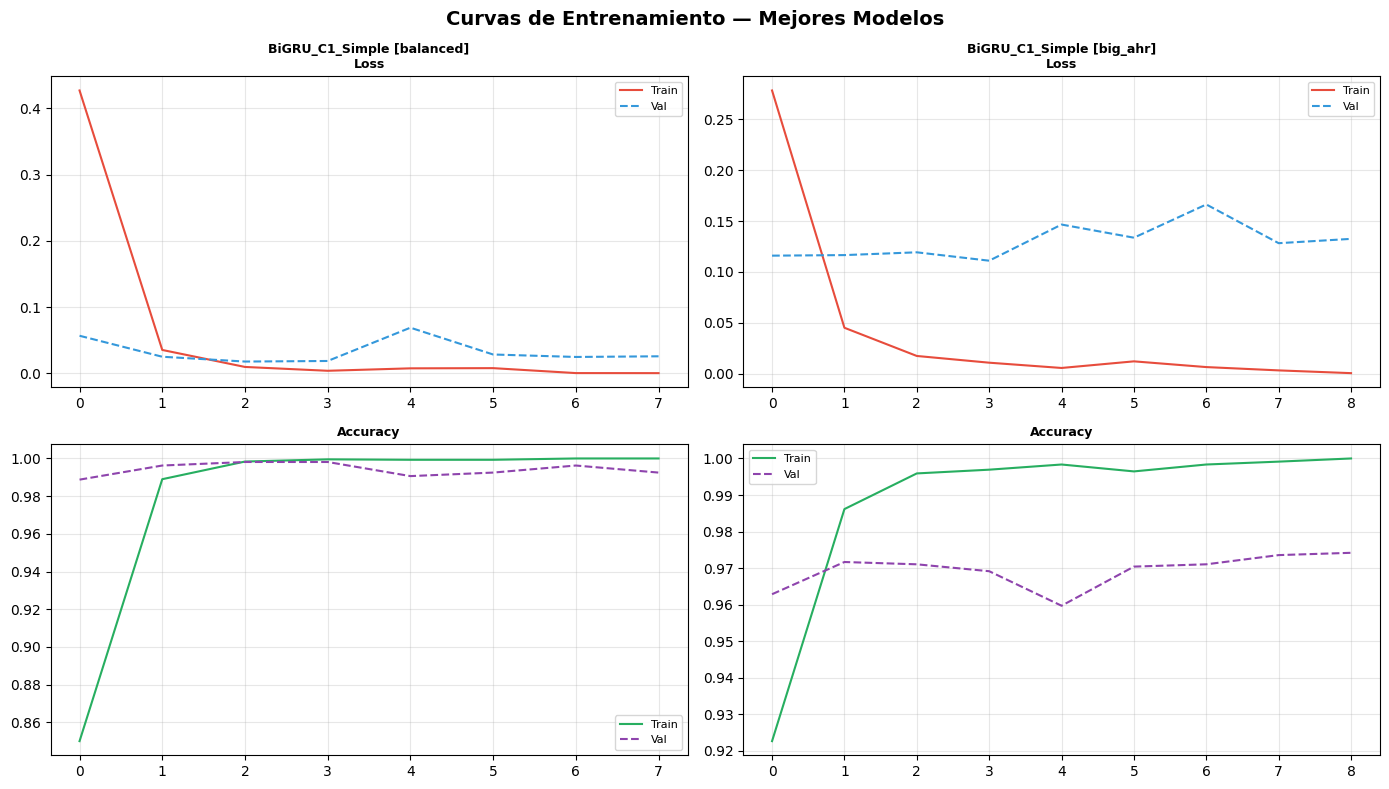

In [19]:
# Extraer mejores configs por dataset
best_configs = {}
for ds in ["balanced","big_ahr"]:
    sub  = df_all[df_all.Dataset==ds].sort_values("F1-Score", ascending=False)
    best = sub.iloc[0]
    best_configs[ds] = {"config": best["Config"], "family": best["Familia"]}
    print(f"  Mejor modelo [{ds}]: {best['Config']} (F1={best['F1-Score']:.4f})")

# Recuperar historiales de los resultados
def get_history(all_results_list, config_name, dataset_name):
    for r in all_results_list:
        if r['config'] == config_name and r['dataset'] == dataset_name:
            return r.get('history', {})
    return {}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Curvas de Entrenamiento — Mejores Modelos", fontsize=14, fontweight='bold')

for col, (ds, info) in enumerate(best_configs.items()):
    cfg_name = info["config"]
    family   = info["family"]
    src      = {"LSTM": lstm_results, "BiGRU": bigru_results, "ConvLSTM": convlstm_results}
    hist     = get_history(src[family], cfg_name, ds)
    if not hist: continue
    axes[0][col].plot(hist['loss'],     color='#e74c3c', label='Train')
    axes[0][col].plot(hist['val_loss'], color='#3498db', label='Val', linestyle='--')
    axes[0][col].set_title(f"{cfg_name} [{ds}]\nLoss", fontsize=9, fontweight='bold')
    axes[0][col].legend(fontsize=8); axes[0][col].grid(alpha=0.3)

    axes[1][col].plot(hist['accuracy'],     color='#27ae60', label='Train')
    axes[1][col].plot(hist['val_accuracy'], color='#8e44ad', label='Val', linestyle='--')
    axes[1][col].set_title(f"Accuracy", fontsize=9, fontweight='bold')
    axes[1][col].legend(fontsize=8); axes[1][col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DIRS["figures"], "FINAL_best_training_curves.png"), dpi=150)
plt.show()

## 8. Conclusiones del Proyecto

In [20]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║         CONCLUSIONES — CLASIFICACIÓN DE SENTIMIENTO AHR          ║
╠══════════════════════════════════════════════════════════════════╣

  1. IMPACTO DEL BALANCEO:
     - El dataset balanceado tiende a producir métricas más uniformes
       (precision/recall equilibrados).
     - El dataset desbalanceado requiere class_weight para evitar sesgo
       hacia la clase mayoritaria (positivo).

  2. COMPARACIÓN DE ARQUITECTURAS:
     - LSTM: Modelo sólido de referencia; stacked LSTM mejora sobre el simple.
     - BiGRU: Captura contexto bidireccional; especialmente útil para texto
              en español con estructuras complejas.
     - Conv1D+BiLSTM: Mejor balance entre velocidad y rendimiento;
                      los filtros convolucionales capturan n-gramas relevantes.

  3. ANÁLISIS DE HIPERPARÁMETROS:
     - Mayor embedding_dim y vocab_size mejoran el rendimiento hasta cierto límite.
     - El dropout excesivo (>0.5) puede perjudicar la convergencia.
     - ReduceLROnPlateau es clave para estabilizar el entrenamiento.

  4. RELEVANCIA PRÁCTICA:
     - Los resultados permiten clasificar reseñas con alta confianza.
     - Aplicable a sistemas de recomendación hotelera en tiempo real.
     - El modelo combinado Conv1D+BiLSTM es el más versátil para producción.

  5. TRABAJO FUTURO:
     - Explorar embeddings preentrenados en español (FastText, Word2Vec ES).
     - Ampliar a clasificación multi-clase (5 estrellas).
     - Técnicas de data augmentation para texto en español.
╚══════════════════════════════════════════════════════════════════╝
""")

# Guardar tabla final
summary_path = os.path.join(DIRS["metrics"], "FINAL_summary.csv")
df_all.to_csv(summary_path, index=False)
print(f"Tabla final guardada: {summary_path}")


╔══════════════════════════════════════════════════════════════════╗
║         CONCLUSIONES — CLASIFICACIÓN DE SENTIMIENTO AHR          ║
╠══════════════════════════════════════════════════════════════════╣

  1. IMPACTO DEL BALANCEO:
     - El dataset balanceado tiende a producir métricas más uniformes
       (precision/recall equilibrados).
     - El dataset desbalanceado requiere class_weight para evitar sesgo
       hacia la clase mayoritaria (positivo).

  2. COMPARACIÓN DE ARQUITECTURAS:
     - LSTM: Modelo sólido de referencia; stacked LSTM mejora sobre el simple.
     - BiGRU: Captura contexto bidireccional; especialmente útil para texto
              en español con estructuras complejas.
     - Conv1D+BiLSTM: Mejor balance entre velocidad y rendimiento;
                      los filtros convolucionales capturan n-gramas relevantes.

  3. ANÁLISIS DE HIPERPARÁMETROS:
     - Mayor embedding_dim y vocab_size mejoran el rendimiento hasta cierto límite.
     - El dropout excesivo 